# Proyecto Integrador: Predictor de demanda para redes eléctricas

## Comprensión del negocio

En este bloque se explora a grandes rasgos los objetivos, fuentes, preparaciones pertinentes y evaluaciones que se realizarán a lo largo del proyecto.

| Bloque | Fase | Descripción |
| --- | --- | --- |
| Objetivo del negocio | Negocio | Predecir la demanda energética para optimizar el uso de fuentes renovables. |
| Valor del proyecto | Negocio | - **Económico:** Optimización de costes de infraestructura, venta de posibles excedentes de energía y menor dependencia de combustibles fósiles. <br><br> - **Medio ambiente:** Reducción en la contaminación del medio ambiente mediante el uso de fuentes renovables. |
| Fuentes de datos | Datos | - **API Red Eléctrica:** API con datos de Red Eléctrica España públicos. https://www.ree.es/es/datos/apidatos <br><br> - **Historial Climático:** Archivo excel con el histórico del clima publicado por la AEMET desde el 2013 hasta la actualidad. https://datosclima.es/Aemet2013/DescargaDatos.html <br><br> - **Calendario Laboral y Festivos:** Librería `holidays` para detectar cuando una fecha es festiva o no en la región. Fichero csv con el calendario de festividades por regiones en su defecto. <br><br> - **Precio diario del Mercado:** A través de la API de Red Eléctrica para predecir con mayor exactitud los precios en función de la demanda y la disponibilidad de energía renovable. |
| Variable objetivo | Datos | **Numérica:** Predicción de consumo para un día determinado en MW. |
| Calidad y riesgos | Datos | - **Calidad:** Pueden existir valores no válidos en los datos obtenidos por la API o el historial climático. <br><br> **Riesgos:** La demanda energética puede depende del calendario (festivos, fines de semana, vacaciones, estaciones...). |
| Preparación y features | Preparación | - Limpieza de datos (filtrado de outliers y nulos, transformaciones, etc.). <br><br> - Creación de variables temporales: `es_festivo`, `es_fin_de_semana`. <br><br> - Inclusión de datos históricos de España desde el 2013 como predictores. <br><br> - Arquitectura de datos con AWS S3 para capas bronce y plata, AWS Lambda y procesamiento local con Pandas. |
| Modelado | Modelado | Uso de algoritmos de regresión basados en series temporales. |
| Evaluación (KPIs) | Evaluación | - **Técnico:** - Obtener un MAPE (Mean Absolute Percentage Error) < 5% y reducir al máximo posible el RMSE (Root Mean Square Error). <br><br> - **Negocio:** Traducir la predicción obtenida en una optimización real; reducción de costes por venta de energía y mayor aprovechación de la cuota de la generación renovable. |
| Despliegue y uso | Despliege | Panel de control o dashboard interactivo para representar los valores de forma rápida y visual. |

## Comprensión de los datos

En este bloque se realizará una exploración rápida sobre los datos disponibles, identificaciones de posibles relaciones y/o modificaciones y transformaciones que puedan ser adecuadas más adelante. 

*Instalación, importaciones de librerías necesarias y definiciones base.*

In [32]:
# Instalaciones
!pip install boto3
!pip install lxml
!pip install beautifulsoup4
!pip install rarfile
!pip install xlrd

In [129]:
# Importaciones y definiciones base
import datetime
import boto3
import pandas as pd
import requests
from urllib.parse import urljoin
import rarfile
import subprocess
import os
import shutil
import io
from bs4 import BeautifulSoup
from requests.exceptions import Timeout, RequestException

API_REE_URL = "https://apidatos.ree.es"
DATOS_CLIMA = "https://datosclima.es/Aemet2013/DescargaDatos.html"

BUCKET_BRONCE = "ksc-proyecto-integrador-bronce"
BUCKET_PLATA = "ksc-proyecto-integrador-plata"

DIR_TEMP = "./tempfiles"

rarfile.UNRAR_TOOl = "/opt/conda/bin/unrar"

def connect_s3():
    try:
        s3 = boto3.client("s3")
        print("Conexión establecida.")
    except Exception as e:
        print("Error de conexión.")
        print(e)

    return s3

def upload_raw_data_to_s3(s3, bucket, filename, data):
    print("Subiendo datos a S3 desde memoria")
    buckets = [b["Name"] for b in s3.list_buckets().get("Buckets", [])]
    existe_bucket = bucket in buckets

    if not existe_bucket:
        s3.create_bucket(Bucket = bucket)

    # Para mantener el df en memoria sin escribirlo al disco
    csv_buffer = io.StringIO()
    data.to_csv(csv_buffer, index = False)

    # s3_key = filename.replace(".xls", ".csv")
    s3_key = filename.replace("-", "/")
    s3_key = os.path.splitext(s3_key)[0]
    s3_key = f"{s3_key}.csv"
    
    s3.put_object(
            Bucket = bucket,
            Key = s3_key,
            Body = csv_buffer.getvalue().encode("utf-8")
        )
    print(f"Datos subidos con éxito a s3://{bucket}/{s3_key}")

def upload_from_disk_to_s3(s3, bucket, path, data):
    buckets = [b["Name"] for b in s3.list_buckets().get("Buckets", [])]
    existe_bucket = bucket in buckets

    if not existe_bucket:
        s3.create_bucket(Bucket = bucket)

    s3.upload_file(data, bucket, path)
    print(f"Datos subidos con éxito a s3://{bucket}/{path}")

Los datos con los que se van a trabajar provienen de: 
- [API de Red Eléctrica](https://apidatos.ree.es)
- [Datos Clima publicados por la AEMET desde el 2013](https://datosclima.es/Aemet2013/DescargaDatos.html)
- Calendario laboral y festivos (librería holiday) TODO

### API Red Eléctrica

In [5]:
endpoint = "/es/datos/demanda/ire-general"

### Datos del clima publicados por la AEMET

Fuente: https://datosclima.es/Aemet2013/DescargaDatos.html

En esta página se encuentran datos publicados por la AEMET desde mayo del 2013 y recogidos de forma libre. Los diferentes enlaces de descarga se encuentran en formato de tabla, divididas por año y mes.

Como descargar uno a uno estos archivos serían un proceso lento y tedioso, se procede a realizar un trabajo de *web scraping* (raspado de web) para las descarga y almacenamiento en AWS S3 de los datos.

In [131]:
def unpack_rar(url, filename, dir = DIR_TEMP):
    filename = filename.split("/")[-1] # Si añade la barra rompe la ruta

    # Comprueba que el directorio existe para borrarlo recursivamente y crearlo otra vez
    if os.path.exists(dir):
        shutil.rmtree(dir)    
    os.makedirs(dir)

    rar_path = os.path.join(dir, filename)

    try:
        print(f"Descargando: {url}")

        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)',
            'Referer': 'https://datosclima.es/Aemet2013/DescargaDatos.html'
        }
        
        response = requests.get(url, stream = True, timeout = (3, 10), headers = headers)
        response.raise_for_status()

        with open(rar_path, "wb") as file:
            for chunk in response.iter_content(chunk_size = 8192):
                file.write(chunk)

        file_kb = os.path.getsize(rar_path)
        if file_kb < 1000:
            print("ERROR: El servidor no ha enviado un .rar")
            with open(rar_path, "r", encoding = "utf-8", errors = "ignore") as f:
                print(f.read())
            return

        print("Descomprimiendo...")
        final_path = os.path.join(dir, "")
        command = ["unrar", "x", "-y", rar_path, final_path]

        process = subprocess.run(command, capture_output = True, text = True)
        print(f"Número de elementos descomprimidos: {len(os.listdir(dir)) - 1}") # -1 porque guarda el .rar también
        return True
    except Timeout:
        print("ERROR: El servidor tardó demasiado en responder.")
        return False
    except Exception as e:
        print(f"ERROR: {e}")
        return False

def convert_files_to_df():
    dfs = []
    
    print("Convirtiendo de excel a DataFrame de pandas")
    tempfiles_path = "tempfiles"
    
    if os.path.exists(tempfiles_path):
        for file in os.listdir(tempfiles_path):
            if file.endswith(".xls"):
                path = os.path.join(tempfiles_path, file)
                try:
                    df = pd.read_excel(path, engine = "xlrd", skiprows = 4)
                    
                    df["archivo_origen"] = file # por si lo necesito más adelante
                    dfs.append((file, df))
                except Exception:
                    # Algún fichero daba error de corrupción o formato
                    continue
    return dfs

# def convert_to_parquet(dfs):
#     print("Convirtiendo de DataFrame de pandas a parquet")
#     path = "parquet"
#     for df in dfs:
#         full_path = os.path.join(path, df.name)
#         df.to_parquet(full_path)

def get_aemet2013_data():
    s3 = connect_s3()
    
    try:
        response = requests.get(DATOS_CLIMA, timeout = (3, 10))
        response.raise_for_status()
        response.encoding = "utf-8"
        
        soup = BeautifulSoup(response.text, "html.parser")
    
        # Captura todos los enlaces en la página
        links = soup.find_all("a")
    
        for link in links:
            path = link.get("href")
    
            if "../capturadatos/" in path:
                full_url = urljoin("https://datosclima.es", path)
                if unpack_rar(full_url, path):
                    dfs = convert_files_to_df()

                    for filename, df in dfs:
                        upload_raw_data_to_s3(s3, BUCKET_BRONCE, filename, df)
    except Timeout:
        print("ERROR: El servidor tardó demasiado en responder.")
    except RequestException as e:
        print(f"ERROR: {e}")

In [132]:
get_aemet2013_data()

Conexión establecida.
Descargando: https://datosclima.es/capturadatos/Aemet2013-05.rar
Descomprimiendo...
Número de elementos descomprimidos: 25
Convirtiendo de excel a DataFrame de pandas
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/Aemet2013/05/07.csv
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/Aemet2013/05/08.csv
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/Aemet2013/05/09.csv
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/Aemet2013/05/10.csv
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/Aemet2013/05/11.csv
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/Aemet2013/05/12.csv
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/Aemet2013/05/13.csv

Para utilizar la librería `rarfile` hace falta tener WinRar o `unrar` instalados en la máquina para poder descomprimir. Como este notebook se asienta en un contenedor de docker con la imagen `jupyter/datascience-notebook` ha sido necesario instalarlo desde `conda` en lugar de hacer el usual `apt-get` que se haría en cualquier caso por falta de permisos. Comando: 

`conda install -c conda-forge unrar -y`

#### Estructura de datos

Los datos se estructuran en unas tablas en la propia web:

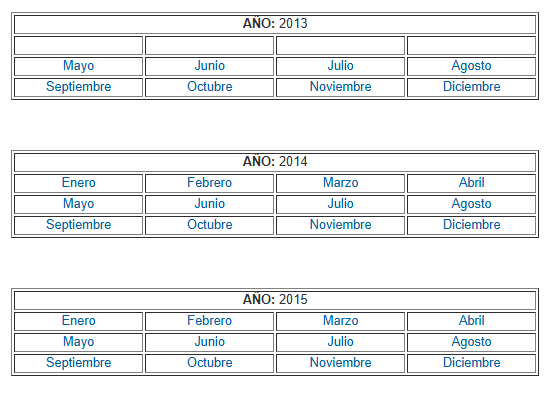

Cada tabla es un año con sus meses. Cada mes es un enlace a un `.rar` que contiene datos de cada día del mes. Así pues, se entiende que al descargar un fichero se descomprime en 30-31 xls.

Se almacenan en AWS S3 por año/mes/(resto de días del mes)

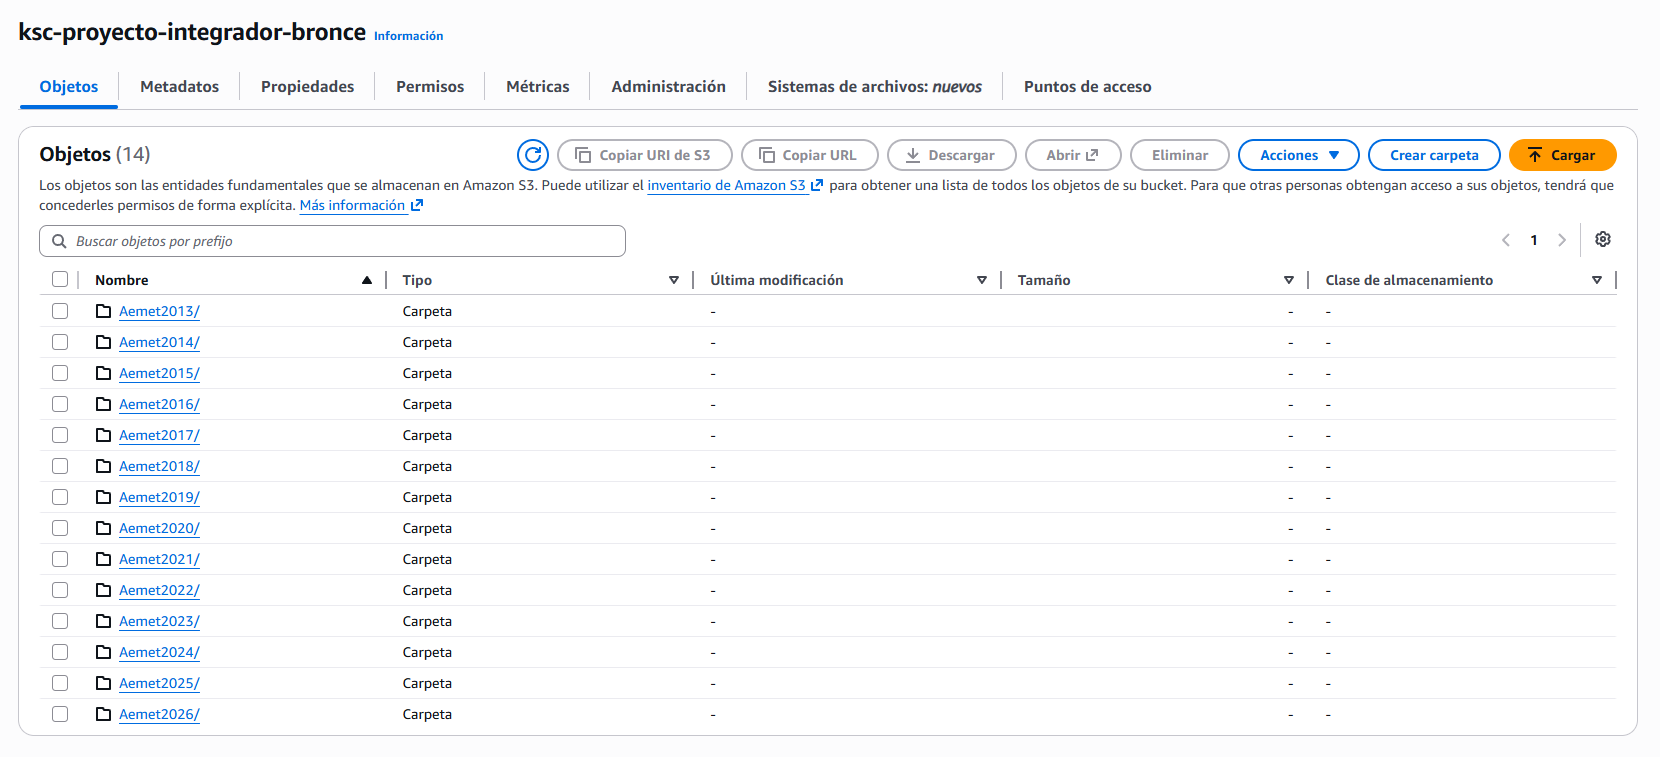